# Support Vector Classifier implenmentation

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline

In [68]:
from sklearn.datasets import make_classification



In [69]:
# create a synthetic data points

X,y = make_classification(
    n_samples= 1000,
    n_features= 2,
    n_classes =2,
    n_clusters_per_class=1,
    n_redundant=0,
    random_state=43
)

In [70]:
X,y

(array([[ 0.12200244, -1.08456794],
        [ 1.33262824,  2.1642212 ],
        [ 0.19828492,  1.97244957],
        ...,
        [ 1.16621703, -1.15226385],
        [ 0.38536591,  1.76767303],
        [-0.974452  ,  1.4640686 ]]),
 array([0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
        0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
        1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
        0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
        0, 0, 1, 0, 1, 0, 1, 

<Axes: xlabel='0', ylabel='1'>

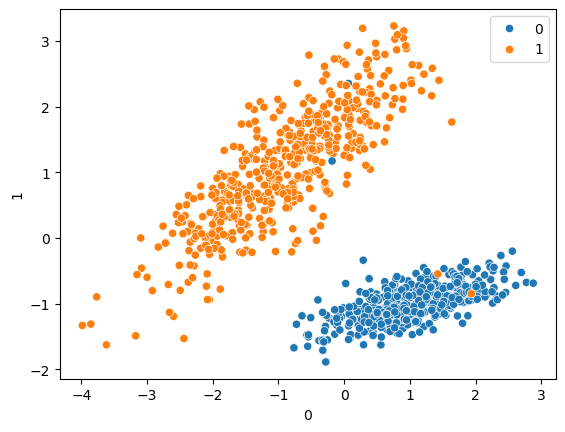

In [71]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue =y)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y, random_state=42,test_size=.25)

In [73]:
from sklearn.svm import SVC

svc = SVC(kernel='linear') #as the the datapoints are clear;y linearly separabale

In [74]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [75]:
svc.coef_ # only present fro linear kernel

array([[-1.1123154 ,  1.17124493]])

In [76]:
y_pred = svc.predict(X_test)

In [77]:
from sklearn.metrics import confusion_matrix,classification_report

In [78]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       130
           1       0.99      0.98      0.99       120

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250

[[129   1]
 [  2 118]]


##### accuracy is 99% as the points are clearly separable .. have 1 cluster each group

## More cluster per class

In [79]:
# create a synthetic data points

X,y = make_classification(
    n_samples= 1000,
    n_features= 2,
    n_classes =2,
    n_clusters_per_class=2,
    n_redundant=0,
    random_state=50
)

<Axes: xlabel='0', ylabel='1'>

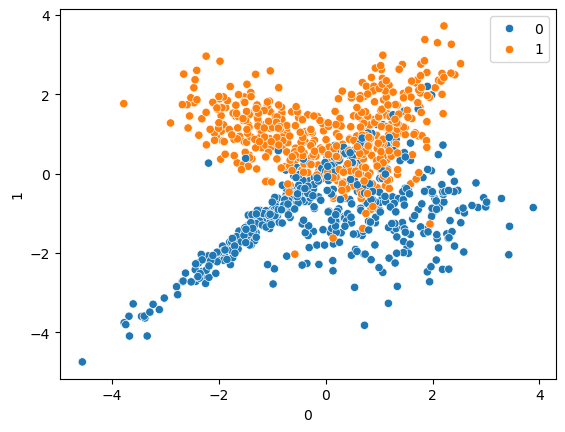

In [80]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue =y)

In [81]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y, random_state=42,test_size=.25)

In [82]:
from sklearn.svm import SVC

svc = SVC(kernel='linear') 

In [83]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [84]:
y_pred = svc.predict(X_test)

In [85]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       124
           1       0.89      0.85      0.87       126

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250

[[111  13]
 [ 19 107]]


# Accuracy droped to 87% as the cluster increased and overlapping happens more
### we need to change the(linear now) kernel type to handle this type of situation

In [86]:
# for RBF kernel

svc = SVC(kernel='rbf')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       124
           1       0.89      0.87      0.88       126

    accuracy                           0.88       250
   macro avg       0.88      0.88      0.88       250
weighted avg       0.88      0.88      0.88       250

[[111  13]
 [ 16 110]]


#### accuracy increased to 88%

In [87]:
# for polynomial kernel

svc = SVC(kernel='poly')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.94      0.87       124
           1       0.92      0.78      0.84       126

    accuracy                           0.86       250
   macro avg       0.87      0.86      0.86       250
weighted avg       0.87      0.86      0.86       250

[[116   8]
 [ 28  98]]


#### for poly accuracy is 86%

In [88]:
# for sigmoid kernel

svc = SVC(kernel='sigmoid')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.78      0.77       124
           1       0.78      0.75      0.76       126

    accuracy                           0.76       250
   macro avg       0.76      0.76      0.76       250
weighted avg       0.76      0.76      0.76       250

[[97 27]
 [32 94]]


#### sigmoid kernel give the worst result 76%

## HyperParameter Tuning

In [89]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C' : [0.1, 1,10,100,1000],
    'gamma' : [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel':['rbf','poly','sigmoid','linear']
}



gridCV = GridSearchCV(estimator=SVC(),
                      param_grid=param_grid,
                      cv =5, 
                      refit=True,
                      scoring ='accuracy',
                      n_jobs=-1,
                      verbose=3)



In [90]:
gridCV

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly', 'sigmoid', 'linear']},
             scoring='accuracy', verbose=3)

In [92]:
gridCV.fit(X_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly', 'sigmoid', 'linear']},
             scoring='accuracy', verbose=3)

In [94]:
gridCV.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [95]:
gridCV.best_score_

np.float64(0.8733333333333334)

In [93]:

y_pred = svc.predict(X_test)
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.78      0.77       124
           1       0.78      0.75      0.76       126

    accuracy                           0.76       250
   macro avg       0.76      0.76      0.76       250
weighted avg       0.76      0.76      0.76       250

[[97 27]
 [32 94]]
